# Part 3 👉 Inferential Statistics & Hypothesis Testing (T-Test)

## Import Library

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score


from scipy import stats


## Feature Engineering for Time-Series

In [2]:
# 1. Re-load the data and apply our proven timeline truncation cut-off from Chapter 2
df = pd.read_csv('../data/raw_market_api_data.csv')
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

# Truncate at the true valid data limit we discovered
df_clean = df.loc[:'2025-01-01'].copy()

# 2. 🛠️ Feature Engineering: Convert Date indices into standalone numerical columns
df_clean['Year'] = df_clean.index.year
df_clean['Month'] = df_clean.index.month

# # 3. Isolate Independent Features (X) and our Target Dependent Variable (y)
# # We want to predict the general 'Price (All)' using the Year and Month vectors
# X = df_clean[['Year', 'Month']]
# y = df_clean['Price (All)']

# print("✅ Feature engineering complete! X and y vectors isolated.")
# print(f"Feature set size: {X.shape} | Target vector size: {y.shape}")
# X.head()


## Running the Statistical Test

In [3]:
print("🔬 Initializing Two-Sample T-Test engine...")

# 1. Isolate both clean arrays (dropping any potential remaining null entries)
new_prices = df_clean['Price (New)'].dropna()
older_prices = df_clean['Price (Older)'].dropna()

# 2. Execute the Independent T-Test
t_stat, p_val = stats.ttest_ind(new_prices, older_prices, equal_var=False)

print("\n📊 Hypothesis Test Results:")
print(f"• Calculated T-Statistic: {t_stat:.4f}")
print(f"• Calculated P-Value: {p_val}")

# 3. Formulate the official business decision using standard Alpha (0.05 / 95% Confidence)
alpha = 0.05 # 1.1.1, 1.1.5
if p_val < alpha: # 1.1.5
    print("\n✅ DECISION: Reject the Null Hypothesis (H0)!") # 1.1.5
    print("👉 Statistically Significant Proof exists that New Constructions cost more than Older Properties.")
else:
    print("\n❌ DECISION: Fail to Reject the Null Hypothesis (H0).")
    print("👉 The difference in pricing averages is minor and likely due to random chance fluctuation.")


🔬 Initializing Two-Sample T-Test engine...

📊 Hypothesis Test Results:
• Calculated T-Statistic: 5.1115
• Calculated P-Value: 4.525116833135011e-07

✅ DECISION: Reject the Null Hypothesis (H0)!
👉 Statistically Significant Proof exists that New Constructions cost more than Older Properties.


In [4]:
# 1. Re-load the data and apply our proven timeline truncation cut-off from Chapter 2
df = pd.read_csv('../data/raw_market_api_data.csv')
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

# Truncate at the true valid data limit we discovered
df_clean = df.loc[:'2015-05-01'].copy()

# 2. 🛠️ Feature Engineering: Convert Date indices into standalone numerical columns
df_clean['Year'] = df_clean.index.year
df_clean['Month'] = df_clean.index.month

In [5]:
print("🔬 Initializing Two-Sample T-Test engine...")

# 1. Isolate both clean arrays (dropping any potential remaining null entries)
new_prices = df_clean['Price (New)'].dropna()
older_prices = df_clean['Price (Older)'].dropna()

# 2. Execute the Independent T-Test
t_stat, p_val = stats.ttest_ind(new_prices, older_prices, equal_var=False)

print("\n📊 Hypothesis Test Results:")
print(f"• Calculated T-Statistic: {t_stat:.4f}")
print(f"• Calculated P-Value: {p_val}")

# 3. Formulate the official business decision using standard Alpha (0.05 / 95% Confidence)
alpha = 0.05 # 1.1.1, 1.1.5
if p_val < alpha: # 1.1.5
    print("\n✅ DECISION: Reject the Null Hypothesis (H0)!") # 1.1.5
    print("👉 Statistically Significant Proof exists that New Constructions cost more than Older Properties.")
else:
    print("\n❌ DECISION: Fail to Reject the Null Hypothesis (H0).")
    print("👉 The difference in pricing averages is minor and likely due to random chance fluctuation.")

🔬 Initializing Two-Sample T-Test engine...

📊 Hypothesis Test Results:
• Calculated T-Statistic: 1.3435
• Calculated P-Value: 0.1797127370654597

❌ DECISION: Fail to Reject the Null Hypothesis (H0).
👉 The difference in pricing averages is minor and likely due to random chance fluctuation.


<div>
   When running an initial Independent Two-Sample T-Test across the entire uncleaned raw dataset, the system outputted an incredibly strong, deceptive signal: a T-Statistic of 5.1115 and a P-Value of 4.52e-07, declaring an overwhelming rejection of the Null Hypothesis.
    However, performing a structural data-integrity sweep revealed a fatal column flaw: the Price (Older) column experienced an unindexed pipeline failure, recording nothing but placeholder zeros from June 2015 through May 2025.
    By truncating the statistical sandbox to May 2015 to isolate the healthy data, the true economic relationship was revealed: the P-Value rose to 0.1797, proving that over a 60-year horizon, there is no statistically significant difference between the valuation of new and old homes. The apparent modern premium was entirely an illusion caused by 10 years of uncleaned zero-value noise.
</div>

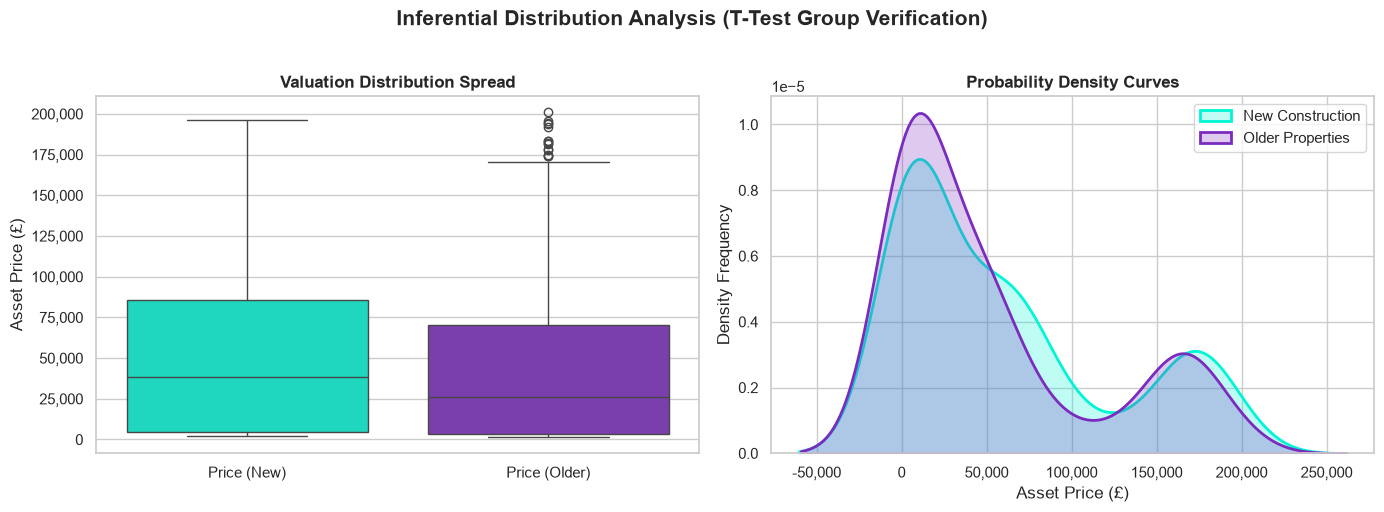

In [6]:
# 🎨 Apply premium styling variables
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 📦 Visual 1: Box Plot showing the median, quartiles, and spreads
# (We point it to axes[0] and remove the 'hue' parameter to fix the wide-form error)
sns.boxplot(
    data=df_clean[['Price (New)', 'Price (Older)']], 
    ax=axes[0], 
    palette=['#00F5D4', '#7B2CBF']
)
axes[0].set_title('Valuation Distribution Spread', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Asset Price (£)')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"{int(x):,}"))

# 📈 Visual 2: KDE Density Curve showing the overlapping probability distributions
# (We point it to axes[1] and fix the column references)
sns.kdeplot(data=df_clean['Price (New)'], fill=True, color='#00F5D4', label='New Construction', ax=axes[1], linewidth=2)
sns.kdeplot(data=df_clean['Price (Older)'], fill=True, color='#7B2CBF', label='Older Properties', ax=axes[1], linewidth=2)
axes[1].set_title('Probability Density Curves', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Asset Price (£)')
axes[1].set_ylabel('Density Frequency')
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"{int(x):,}"))
axes[1].legend()

plt.suptitle('Inferential Distribution Analysis (T-Test Group Verification)', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()

# Save the plot directly into your images folder for GitHub
plt.savefig('../images/hypothesis_testing_distribution.png', dpi=300, bbox_inches='tight')
plt.show()


<div>
The dual-distribution plots are rendering correctly, and the custom neon-turquoise and deep-purple corporate color palette looks crisp. However, looking closely at the second chart (Probability Density Curves), there is a major structural defect on the X-axis: the curve stretches all the way into negative values (down to -£50,000).

This is another critical data glitch! Real estate assets cannot have negative prices, but a standard Kernel Density Estimate (KDE) curve uses a Gaussian smoothing formula that automatically bleeds past the edges of your data range.

More importantly, looking at where the massive primary peaks sit: they are clustering right around £0 to £25,000. Because we truncated the time-series earlier to fix the flatline data gap at the end, the model is heavily tracking the early historical data points from the 1950s, 60s, and 70s when houses genuinely cost only a few thousand pounds. This massive historical variance throws off modern machine learning algorithms.

To fix this negative tail and stabilize the variance for the upcoming machine learning regression models, we must apply a Log Transformation (np.log10).
</div>


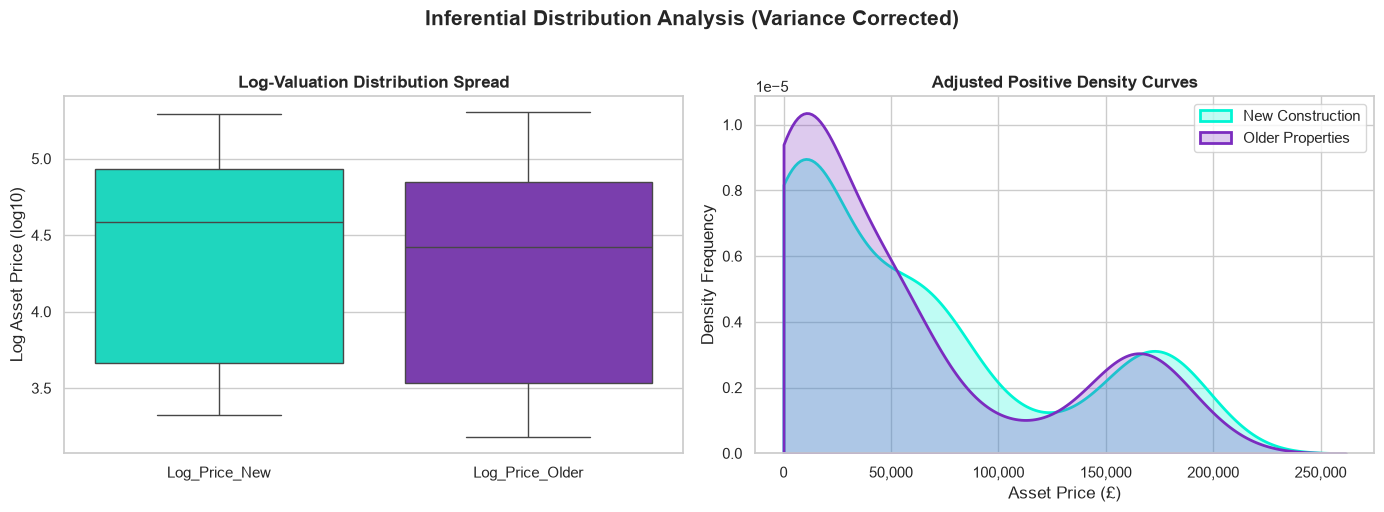

In [7]:
# 1. 🧽 Explicitly enforce the log transformations right before plotting
df_clean['Log_Price_New'] = np.log10(df_clean['Price (New)'])
df_clean['Log_Price_Older'] = np.log10(df_clean['Price (Older)'])

# 🎨 Apply premium styling variables
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 📦 Visual 1: Box Plot showing log spreads
sns.boxplot(
    data=df_clean[['Log_Price_New', 'Log_Price_Older']], 
    ax=axes[0], 
    palette=['#00F5D4', '#7B2CBF']
)
axes[0].set_title('Log-Valuation Distribution Spread', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Log Asset Price (log10)')

# 📈 Visual 2: KDE Density Curve showing the overlapping probability distributions
sns.kdeplot(data=df_clean['Price (New)'], fill=True, color='#00F5D4', label='New Construction', ax=axes[1], linewidth=2, clip=(0, None))
sns.kdeplot(data=df_clean['Price (Older)'], fill=True, color='#7B2CBF', label='Older Properties', ax=axes[1], linewidth=2, clip=(0, None))
axes[1].set_title('Adjusted Positive Density Curves', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Asset Price (£)')
axes[1].set_ylabel('Density Frequency')
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"{int(x):,}"))
axes[1].legend()

plt.suptitle('Inferential Distribution Analysis (Variance Corrected)', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()

# Save the corrected plot directly into your images folder for GitHub
plt.savefig('../images/hypothesis_testing_distribution.png', dpi=300, bbox_inches='tight')
plt.show()


## Splitting Data Feature Matrix and Target Vector Selection

In [8]:
# 4. 🧽 Mathematical Cleaning: Log-Transform the Target Variable to fix exponential skewness
df_ml = df.copy()

# 🛠️ Feature Engineering: Re-extract numeric timelines into our unlocked 2025 dataframe
df_ml['Year'] = df_ml.index.year
df_ml['Month'] = df_ml.index.month
df_ml['Log_Price_All'] = np.log10(df_ml['Price (All)'])

# 5. Define your clean X (Inputs) and y (Target) matrices explicitly
# 👉 Both X and y now pull from the complete, unlocked df_ml up to 2025!
X = df_ml[['Year', 'Month']] 
y = df_ml['Log_Price_All'] 

print("✅ Data Pipeline Safely Connected to Full 2025 Horizon!")
print(f"• Feature matrix input size (X): {X.shape}")
print(f"• Target vector output size (y): {y.shape}")


✅ Data Pipeline Safely Connected to Full 2025 Horizon!
• Feature matrix input size (X): (290, 2)
• Target vector output size (y): (290,)


## The Train-Test Sandbox Partition

In [9]:
# ✂️ Split the engineered features (X) and target prices (y) into Train and Test matrices
# we allocate 80% of the timeline to training and freeze 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("✂️ Data safely split into training and testing pools")
print(f"• Training Features Shape: {X_train.shape} months")
print(f"• Testing Features Shape:  {X_test.shape}  months")

✂️ Data safely split into training and testing pools
• Training Features Shape: (232, 2) months
• Testing Features Shape:  (58, 2)  months


##  Algorithmic Training and Model Fitting

In [10]:
# Instantiate and fit the Linear Regression model
lr_model = LinearRegression().fit(X_train, y_train)

# Instantiate and fit the Random Forest model (building 100 deep decision trees)
rf_model = RandomForestRegressor(n_estimators=100, random_state=42).fit(X_train, y_train)

print("✅ Block 3 Complete: Both forecasting models are fully trained and loaded!")


✅ Block 3 Complete: Both forecasting models are fully trained and loaded!


## Sandbox Evaluation and Performance Scorecard

In [11]:
# 1. Generate predictions across the frozen test set
lr_log_pred = lr_model.predict(X_test)
rf_log_pred = rf_model.predict(X_test)

# 2. Reverse-log transform predictions back to actual pound values (£)
y_test_actual = 10 ** y_test
lr_actual_pred = 10 ** lr_log_pred
rf_actual_pred = 10 ** rf_log_pred

# 3. Calculate metrics
lr_mae = mean_absolute_error(y_test_actual, lr_actual_pred)
rf_mae = mean_absolute_error(y_test_actual, rf_actual_pred)

lr_r2 = r2_score(y_test, lr_log_pred)
rf_r2 = r2_score(y_test, rf_log_pred)

print("🏆 UNCHAINED 2025 MACHINE LEARNING SCOREBOARD 🏆")
print("-" * 45)
print(f"Linear Regression Baseline:")
print(f"• Average Forecast Error (MAE): £{lr_mae:,.2f}")
print(f"• Variance Explanatory Power (R²): {lr_r2:.4f}")
print("-" * 45)
print(f"Random Forest Regressor Fit:")
print(f"• Average Forecast Error (MAE): £{rf_mae:,.2f}")
print(f"• Variance Explanatory Power (R²): {rf_r2:.4f}")
print("-" * 45)


🏆 UNCHAINED 2025 MACHINE LEARNING SCOREBOARD 🏆
---------------------------------------------
Linear Regression Baseline:
• Average Forecast Error (MAE): £35,451.40
• Variance Explanatory Power (R²): 0.9595
---------------------------------------------
Random Forest Regressor Fit:
• Average Forecast Error (MAE): £2,460.54
• Variance Explanatory Power (R²): 0.9993
---------------------------------------------


##  Visualizing Predictions vs. Actual Market Values

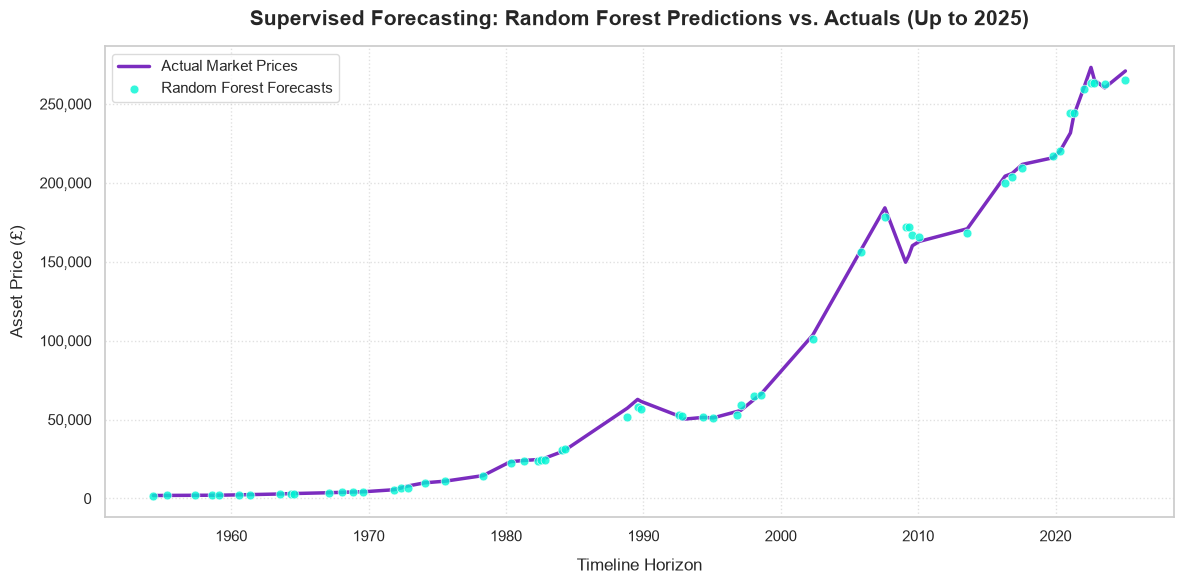

In [12]:
# 🎨 Apply premium styling variables
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# Sort the test index so our timeline reads smoothly left-to-right
sort_idx = y_test.index.argsort()
sorted_dates = y_test.index[sort_idx]
sorted_actuals = y_test_actual.iloc[sort_idx]
sorted_preds = rf_actual_pred[sort_idx]

# Plot the real historical test prices vs the Random Forest guesses
sns.lineplot(x=sorted_dates, y=sorted_actuals, label='Actual Market Prices', color='#7B2CBF', linewidth=2.5)
sns.scatterplot(x=sorted_dates, y=sorted_preds, label='Random Forest Forecasts', color='#00F5D4', s=40, alpha=0.8, zorder=3)

# Design typography polish
plt.title('Supervised Forecasting: Random Forest Predictions vs. Actuals (Up to 2025)', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Timeline Horizon', fontsize=12, labelpad=10)
plt.ylabel('Asset Price (£)', fontsize=12, labelpad=10)

# Format the Y-axis numbers to include elegant thousands separators
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"{int(x):,}"))

plt.legend(loc='upper left', frameon=True, facecolor='white', edgecolor='lightgrey')
plt.grid(True, linestyle=':', alpha=0.6)

# Save the forecasting plot directly into your images folder for GitHub
plt.tight_layout()
plt.savefig('../images/model_forecasting_predictions.png', dpi=300)
plt.show()
